In [36]:
import sys, os
sys.path.append('..')
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from func import custom_loss

In [37]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)

gym.init_arena_map(shape="rectangle")

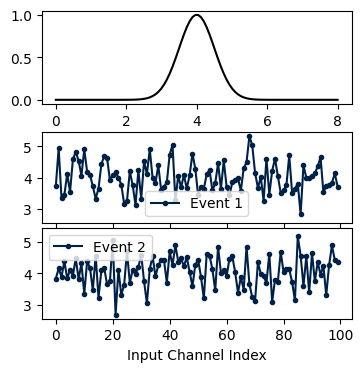

In [38]:
# Plot the normal distribution which is used to sample the temporal events
x = np.linspace(0, 8, 100)
mu, sigma = 4.0, 0.5
y = np.exp(-(x - mu)**2 / (2 * sigma**2))
# Sample 100 points from the normal distribution
samples1 = np.random.normal(mu, sigma, 100)
samples2 = np.random.normal(mu, sigma, 100)

fig = plt.figure(figsize=(4, 4))

# Outer grid: controls gap between ax[0] and the lower block
outer = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.2)

ax0 = fig.add_subplot(outer[0, 0])

# Inner grid: controls ONLY gap between ax[1] and ax[2]
inner = outer[1, 0].subgridspec(2, 1, hspace=0.05)
ax1 = fig.add_subplot(inner[0, 0])
ax2 = fig.add_subplot(inner[1, 0], sharex=ax1, sharey=ax1)

# your plotting
ax0.plot(x, y, 'k')
ax1.plot(np.arange(len(samples1)), samples1, '.-', label='Event 1', color='#002147')
ax2.plot(np.arange(len(samples2)), samples2, '.-', label='Event 2', color='#002147')

ax1.tick_params(axis='x', labelbottom=False)
ax2.set_xlabel('Input Channel Index')
ax1.legend(loc='best')
ax2.legend(loc='best')

In [39]:
behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          0.1,
                    "velocity_sd":            0.0,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1
                    }

# Generate the first temporal event with shape n_channels, Select fixed random number from a normal distribution
n_channels = 100
np.random.seed(42)  # For reproducibility
temp_event_1 = np.random.normal(loc=mu, scale=sigma, size=(n_channels,))
temp_event_2 = np.random.normal(loc=mu, scale=sigma, size=(n_channels,))

sensory_profile = {
                    "time": {
                            "type":        "time_cell",
                            "n_cells":     n_channels,
                            "event_onset": [0.0625, 0.4375],     # 2.5s, 17.5s 
                            "event_width": [0.0125, 0.0125],     # 0.5s, 0.5s
                            "temp_events": [temp_event_1, temp_event_2],  # List of temporal events
                            "event_onset_sigma": [0.005, 0.005], # 0.005 x 40s = 0.2s
                            "sigma":       0.5,    # sigma of Gaussian noise
                            "ssigma":      0.2,    # smoothing sigma of Gaussian noise (in sec)
                            "bias":        0.
                            },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

# Generate (Batch size) trial
gym.trial.new_trial(duration=40, batch_size=128) # much longer duration

# Get some specific responses within a time range, the key should be the same as the sensory profile
time_res = gym.trial.get_responses(keys='time')
print('time responses:', time_res.shape)

<class 'rtgym.trial.trial.Trajectory'>
time responses: (128, 400, 100)


In [40]:
traj = gym.trial.get_traj()
traj['coords'] = traj['coords_float'] 
traj['hds'] = traj['head_directions']
traj['disps'] = traj['displacements']
del traj['coords_float']
del traj['head_directions']
del traj['displacements']
print(traj.keys())

dict_keys(['coords', 'hds', 'disps'])


Text(0, 0.5, 'Channels')

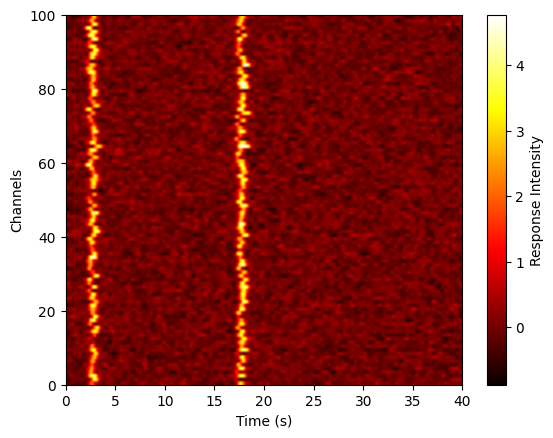

In [57]:
# Plot the time_res
plt.imshow(time_res[0].T, aspect='auto', cmap='hot', 
           extent=[0, time_res.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [ ]:
inputs = time_res.copy()

# Mask the inputs
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.3,    # Maximum masking ratio
                m_min=0.1,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )
inputs = mask.mask(inputs).numpy()

In [59]:
# Plot the masked inputs (OPTIONAL, depending on the task)
mask_start_idx = int(inputs.shape[1]*(sensory_profile['time']['event_onset'][0]+\
                                      sensory_profile['time']['event_width'][0]+\
                                      sensory_profile['time']['event_onset_sigma'][0]))
print('Mask start index:', mask_start_idx)
inputs[:, mask_start_idx:, :] = 0

Mask start index: 32


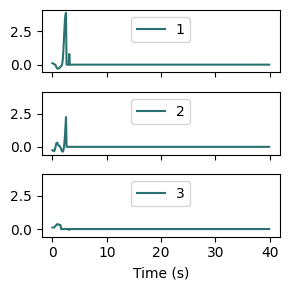

In [67]:
fig, ax = plt.subplots(3, 1, figsize=(3, 3), sharex=True, sharey=True)
for i, channel in enumerate(range(5, 8)):
    ax[i].plot(np.arange(inputs.shape[1]) * temp_reso / 1000, 
               inputs[0, :, channel], 
               label=f'{i+1}', color='#297270')
    # Pit the legend at the upper middle of the plot
    ax[i].legend(loc='upper center')
ax[-1].set_xlabel('Time (s)')
plt.tight_layout()

In [68]:
import torch
import nn4n.nn

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

num_neuron = 512

model_cfg = {
            "input_dim":    inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   inputs.shape[2],
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: mps


In [70]:
state_dict = torch.load('../../model/2TS.pth', map_location=device)
rnn.load_state_dict(state_dict)
rnn.to(device)
print("Model loaded successfully.")

Model loaded successfully.


In [71]:
inputs = torch.from_numpy(inputs).float().to(device)

rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (128, 400, 100)
hidden states: <class 'numpy.ndarray'> (128, 400, 512)


Text(0, 0.5, 'Channels')

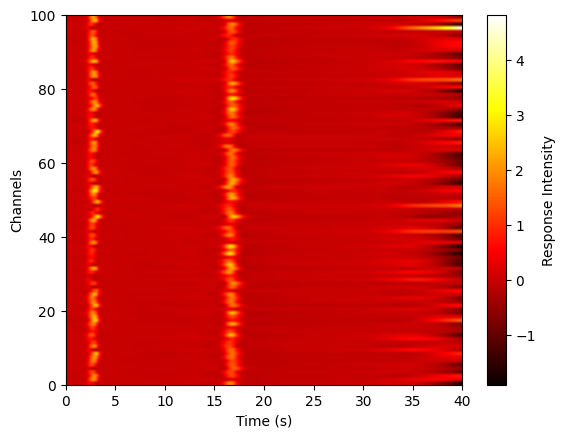

In [72]:
# Plot the outputs
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

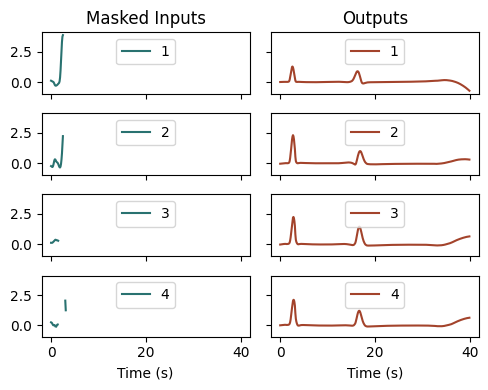

In [80]:
plot_inputs = inputs.cpu().numpy().copy()
plot_labels = time_res
plot_outputs = test_outputs

# Convert the zero values to nan for better visualization
plot_inputs[plot_inputs == 0] = np.nan

fig, ax = plt.subplots(4, 2, figsize=(5, 4), sharex=True, sharey=True)
for i, channel in enumerate(range(5, 9)):
    
    ax[i][0].plot(np.arange(plot_inputs.shape[1]) * temp_reso / 1000, 
                 plot_inputs[0, :, channel], 
                 label=f'{i+1}', color='#297270')
    ax[i][0].legend(loc='upper center')
    
    ax[i][1].plot(np.arange(plot_outputs.shape[1]) * temp_reso / 1000, 
                  plot_outputs[0, :, channel], 
                  label=f'{i+1}', color='#A3432B')
    ax[i][1].legend(loc='upper center')
ax[0][0].set_title('Masked Inputs')
ax[0][1].set_title('Outputs')
ax[-1][0].set_xlabel('Time (s)')
ax[-1][1].set_xlabel('Time (s)')
plt.tight_layout()

(400, 512)
(400, 77)


Text(0.5, 0, 'Time (s)')

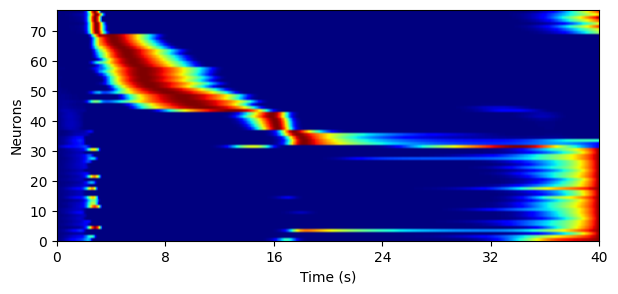

In [84]:
from func import plt_hs
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

# Plot the sorted hidden states
fig, ax = plt.subplots(figsize=(7, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')

In [82]:
# Save the data
save_dict = {
            'test_inputs': inputs.cpu().numpy(),
            'test_labels': time_res.copy(), 
            'test_outputs': test_outputs,
            'test_hidden_states': hidden_states,
        }
os.makedirs('../../data', exist_ok=True)
np.save('../../data/2TS_test_longer.npy', save_dict)